<a href="https://colab.research.google.com/github/jbkim900/Big-data-Analysis-Class_2026.03.12/blob/main/Chapter08_%ED%95%9C%EA%B8%80%EB%B6%84%EC%84%9D_%EC%9B%8C%EB%93%9C%ED%81%B4%EB%9D%BC%EC%9A%B0%EB%93%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 6 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/n

In [2]:
import json
import re
!pip install konlpy
from konlpy.tag import Okt
from collections import Counter
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import font_manager, rc
from wordcloud import WordCloud

In [3]:
inputFileName = '아시안컵_naver_news'
data = json.loads(open(inputFileName+'.json', 'r', encoding = 'utf-8').read())

data #출력하여 내용 확인

[{'cnt': 1,
  'description': '그동안 월드컵 3개 대회(2014 브라질·2018 러시아·2022 카타르)와 <b>아시안컵</b> 3개 대회(2015 호주·2019 아랍에미리트·2023 카타르)를 뛰었으며, 어쩌면 마지막이 될 수 있는 2026 북중미 월드컵을 준비 중이다. 현재까지... ',
  'link': 'https://www.newsis.com/view/NISX20260326_0003565024',
  'org_link': 'https://www.newsis.com/view/NISX20260326_0003565024',
  'pDate': '2026-03-26 14:23:00',
  'title': "'전설' 차범근 넘는다…손흥민, 한국 A매치 최다골 대기록까지 '-4'"},
 {'cnt': 2,
  'description': '올해는 2026아이치·나고야<b>아시안</b>게임이 열린다. 대표팀은 공희용이 <b>아시안</b>게임 전까지 온전한 컨디션을 되찾길 기대한다. 그가 제때 몸상태를 끌어올리지 못하면 금메달에 도전하는 여자복식과 여자단체전서 전망이... ',
  'link': 'https://sports.donga.com/sports/article/all/20260326/133610352/1',
  'org_link': 'https://sports.donga.com/sports/article/all/20260326/133610352/1',
  'pDate': '2026-03-26 14:04:00',
  'title': '女 복식 간판 공희용, 오른쪽 무릎 부상으로 수술대 올라…AG 출전은 이...'},
 {'cnt': 3,
  'description': 'U-23 <b>아시안컵</b>에서 4강에 그쳤다. 일본이라는 벽에 막히며 결승 진출이 좌절됐다. 한국과 달리 선수단을 21세 이하(U-21)로 구성한 일본이었기에 패배는 더 뼈아팠다. 9월 아이치-나고야 아시안게임까지의 도전에서 일본을... ',
  'link': 'http

In [4]:
description = ''
for item in data:
    if 'description' in item.keys():
        description = description + re.sub(r'[^\w]', ' ', item['description']) +''

description #출력하여 내용 확인


'그동안 월드컵 3개 대회 2014 브라질 2018 러시아 2022 카타르 와  b 아시안컵  b  3개 대회 2015 호주 2019 아랍에미리트 2023 카타르 를 뛰었으며  어쩌면 마지막이 될 수 있는 2026 북중미 월드컵을 준비 중이다  현재까지    올해는 2026아이치 나고야 b 아시안  b 게임이 열린다  대표팀은 공희용이  b 아시안  b 게임 전까지 온전한 컨디션을 되찾길 기대한다  그가 제때 몸상태를 끌어올리지 못하면 금메달에 도전하는 여자복식과 여자단체전서 전망이    U 23  b 아시안컵  b 에서 4강에 그쳤다  일본이라는 벽에 막히며 결승 진출이 좌절됐다  한국과 달리 선수단을 21세 이하 U 21 로 구성한 일본이었기에 패배는 더 뼈아팠다  9월 아이치 나고야 아시안게임까지의 도전에서 일본을    2026 아이치 나고야  b 아시안  b 게임 개막이 6개월 앞으로 다가왔다  이민성 감독이 이끄는 한국 23세 이하 U 23  대표팀이 점차 윤곽을 드러내고 있다   b 아시안  b 게임에서 금메달을 획득하면 병역법에 따라 예술체육요원으로    1990년  b 아시안  b 게임 도입 이후 단 한 번도 패한 적이 없었다는 점을 고려하면 이는 전 세계 카바디계를 경악시킨 작은 기적이었다  그 중심에는 여전히 건재한 이장군이 있다  그는 2024년 대만 국제 대회 윈디 시티  b 컵  b  에서    베트남축구연맹 VFF 에 따르면  이는 2027년 아시아축구연맹 AFC   b 아시안컵  b  예선 F조 조별경기에서 발생한    특히 F조 선두 자리를 베트남에 내주며  b 아시안컵  b  본선 진출 가도에도 빨간불이 켜졌다  순위 상승으로    코다는 올 시즌 개막전 우승후  b 아시안  b  스윙을 건너뛰며 재충전의 시간을 가졌다  장타를 앞세운 공격적인 플레이가 이번 주 어떤 시너지를 낼지 궁금하다  이번 포드 챔피언십은 넬리 코다의 언니인 제시카 코다 33 의    2023 아시아축구연맹 AFC  카타르  b 아시안컵  b 에서 실수를 

In [5]:
nlp = Okt()
description_N = nlp.nouns(description)
description_N #출력하여 내용 확인

['그동안',
 '월드컵',
 '개',
 '대회',
 '브라질',
 '러시아',
 '카타르',
 '아시안컵',
 '개',
 '대회',
 '호주',
 '아랍에미리트',
 '카타르',
 '를',
 '어쩌면',
 '마지막',
 '수',
 '북',
 '중미',
 '월드컵',
 '준비',
 '중이',
 '현재',
 '올해',
 '아이치',
 '나고야',
 '아시안',
 '게임',
 '린다',
 '대표팀',
 '공',
 '용이',
 '아시안',
 '게임',
 '전',
 '온전',
 '컨디션',
 '그',
 '제때',
 '몸',
 '상태',
 '리지',
 '금메달',
 '도전',
 '여자',
 '복식',
 '여자',
 '단체',
 '전서',
 '전망',
 '아시안컵',
 '강',
 '일본',
 '벽',
 '결승',
 '진출',
 '좌절',
 '한국',
 '달리',
 '선수단',
 '세',
 '이하',
 '로',
 '구성',
 '일본',
 '패배',
 '더',
 '뼈',
 '아이치',
 '나고야',
 '아시안',
 '게임',
 '도전',
 '일본',
 '아이치',
 '나고야',
 '아시안',
 '게임',
 '개막',
 '개월',
 '앞',
 '이민성',
 '감독',
 '한국',
 '세',
 '이하',
 '대표팀',
 '점차',
 '윤곽',
 '아시안',
 '게임',
 '금메달',
 '획득',
 '병역법',
 '예술',
 '체육',
 '요원',
 '아시안',
 '게임',
 '도입',
 '이후',
 '단',
 '번',
 '패',
 '적',
 '점',
 '고려',
 '전',
 '세계',
 '카바디',
 '경악',
 '기적',
 '그',
 '중심',
 '건재',
 '장군',
 '그',
 '대만',
 '국제',
 '대회',
 '윈디',
 '시티',
 '컵',
 '베트남',
 '축구',
 '연맹',
 '아시아',
 '축구',
 '연맹',
 '아시안컵',
 '예선',
 '조',
 '경기',
 '발생',
 '조',
 '선두',
 '자리',
 '베트남',
 '아시안컵',
 '본선',
 '진

In [6]:
count = Counter(description_N)
count #출력하여 내용 확인

Counter({'그동안': 1,
         '월드컵': 170,
         '개': 29,
         '대회': 248,
         '브라질': 35,
         '러시아': 2,
         '카타르': 15,
         '아시안컵': 1263,
         '호주': 488,
         '아랍에미리트': 3,
         '를': 6,
         '어쩌면': 1,
         '마지막': 23,
         '수': 34,
         '북': 1,
         '중미': 1,
         '준비': 38,
         '중이': 4,
         '현재': 38,
         '올해': 34,
         '아이치': 101,
         '나고야': 103,
         '아시안': 337,
         '게임': 257,
         '린다': 4,
         '대표팀': 564,
         '공': 4,
         '용이': 1,
         '전': 119,
         '온전': 1,
         '컨디션': 2,
         '그': 40,
         '제때': 1,
         '몸': 3,
         '상태': 4,
         '리지': 1,
         '금메달': 70,
         '도전': 51,
         '여자': 1037,
         '복식': 1,
         '단체': 5,
         '전서': 2,
         '전망': 5,
         '강': 233,
         '일본': 449,
         '벽': 6,
         '결승': 102,
         '진출': 149,
         '좌절': 5,
         '한국': 465,
         '달리': 3,
         '선수단': 17,
        

In [7]:
word_count = dict()

for tag, counts in count.most_common(100):
    if(len(str(tag))>1):
        word_count[tag] = counts
        print("%s : %d" % (tag, counts))

아시안컵 : 1263
여자 : 1037
축구 : 980
대표팀 : 564
연맹 : 515
호주 : 488
아시아 : 486
한국 : 465
일본 : 449
아시안 : 337
감독 : 302
게임 : 257
대회 : 248
스타디움 : 234
시드니 : 225
경기 : 216
선수 : 193
오스트레일리아 : 185
준결승 : 181
월드컵 : 170
이란 : 168
우승 : 157
강전 : 152
진출 : 149
시간 : 143
신상우 : 143
지난 : 141
이번 : 123
대한민국 : 123
국제 : 122
개최 : 122
출전 : 121
협회 : 116
우즈베키스탄 : 115
본선 : 110
나고야 : 103
결승 : 102
아이치 : 101
승리 : 98
이하 : 82
현지 : 79
이후 : 74
금메달 : 70
리그 : 67
중국 : 64
이민성 : 62
내년 : 60
오후 : 58
소집 : 56
도전 : 51
미국 : 51
전반 : 51
선수권 : 50
위해 : 50
참가 : 48
최근 : 48
연속 : 48
국가대표팀 : 47
훈련 : 46
선정 : 46
결과 : 45
국가 : 44
한일전 : 44
결승전 : 43
국내 : 42
진행 : 42
절차 : 42
예선 : 41
정상 : 41
사상 : 40
대비 : 39
연령 : 39
망명 : 39
준비 : 38
현재 : 38
세계 : 38
동아시아 : 38
무대 : 37
투어 : 37
사진 : 36
기록 : 36
차지 : 36


In [12]:
font_path = "/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf"
# font_path = "c:/Windows/fonts/malgun.ttf"
font_name = font_manager.FontProperties( fname = font_path).get_name()
matplotlib.rc('font', family = font_name)

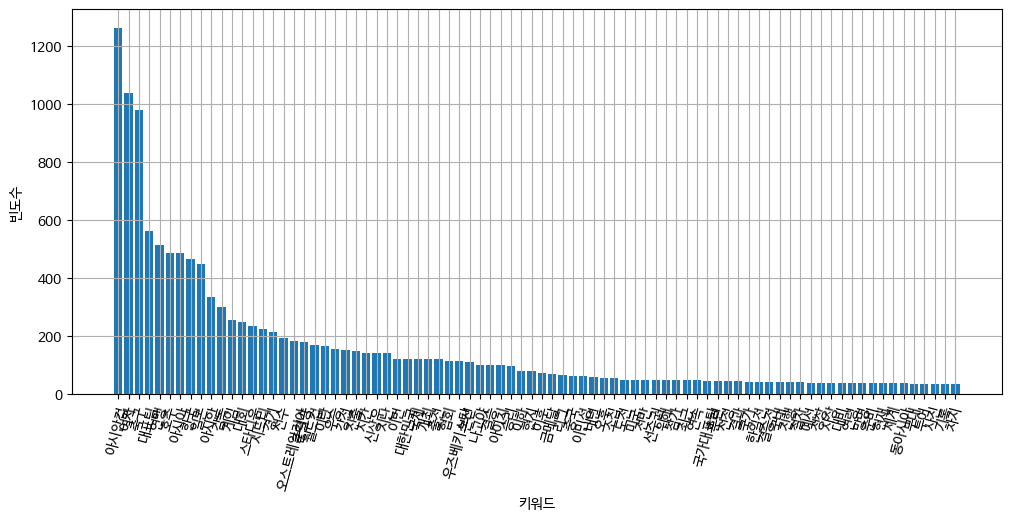

In [13]:
plt.figure(figsize = (12, 5))
plt.xlabel('키워드')
plt.ylabel('빈도수')
plt.grid(True)
sorted_Keys = sorted(word_count, key = word_count.get, reverse = True)
sorted_Values = sorted(word_count.values(), reverse = True)
plt.bar(range(len(word_count)), sorted_Values, align = 'center')
plt.xticks(range(len(word_count)), list(sorted_Keys), rotation = 75)
plt.show()

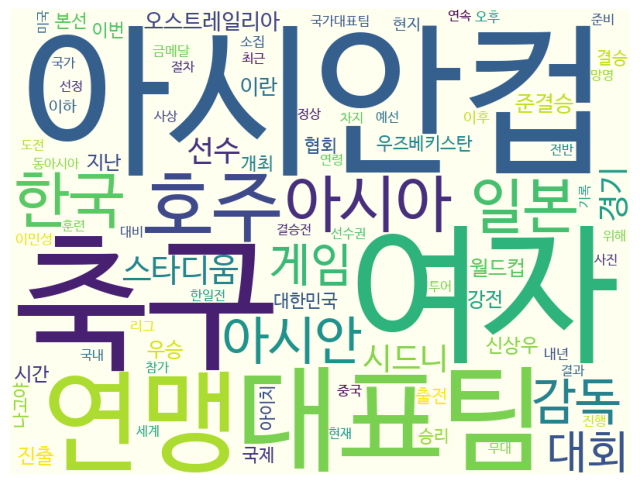

In [14]:
wc = WordCloud( font_path, background_color = 'ivory', width = 800, height = 600)
cloud = wc.generate_from_frequencies(word_count)
plt.figure(figsize = (8, 8))
plt.imshow(cloud)
plt.axis('off')
plt.show()

In [15]:
cloud.to_file(inputFileName + '_cloud.jpg')